In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import rcParams


sns.set_style()
sns.set_context('paper')

rcParams['figure.figsize'] = (12, 8)

In [2]:
df = pd.read_stata("03_merged/merged.dta")
df = df.copy()

In [3]:
# 1. Create the index if not already done
tar_dummies_for_beating = ['GR34', 'GR35', 'GR36', 'GR37', 'GR38', 'GR39']
df = df.dropna(subset=tar_dummies_for_beating)
for dum in tar_dummies_for_beating:
    df[dum] = df[dum].cat.rename_categories({"Yes 1" : 1, "No 0" : 0}).astype(int)

df['wifebeat_index'] = df[tar_dummies_for_beating].mean(axis=1)

# 2. Log consumption
df['ln_COPC'] = np.log(df['COPC'])

# 3. Summary statistics for continuous variables
cont_vars = ['wifebeat_index', 'ln_COPC', 'EW6', 'EW8', 'SPED6']

In [4]:
df['EW8'] = df['EW8'].cat.codes
df['SPED6'] = df['SPED6'].cat.codes
df['URBAN2011'] = df['URBAN2011'].cat.codes

\begin{tabular}{lrrrrr}
\toprule
 & Mean & Std. Dev. & Min & Max & N \\
\midrule
Wife-beating index & 0.48 & 0.34 & 0.00 & 1.00 & 39357 \\
Log consumption per capita & 9.90 & 0.67 & 6.56 & 14.20 & 39348 \\
Age & 36.33 & 9.87 & 15.00 & 81.00 & 39357 \\
Years of education (self) & 5.18 & 4.92 & -1.00 & 16.00 & 39357 \\
Years of education (spouse) & 6.58 & 5.09 & -1.00 & 16.00 & 39357 \\
Urban (=1) & 0.34 & 0.47 & 0.00 & 1.00 & 39357 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
 & Mean & Std. Dev. & N \\
\midrule
Never & 0.513000 & 0.335000 & 7325 \\
Sometimes & 0.531000 & 0.338000 & 8853 \\
Regularly & 0.456000 & 0.334000 & 22934 \\
\bottomrule
\end{tabular}

\begin{tabular}{lr}
\toprule
Group & Share \\
\midrule
Brahmin 1 & 5.000000 \\
Forward caste 2 & 17.000000 \\
Other Backward Castes (OBC) 3 & 33.800000 \\
Dalit 4 & 21.300000 \\
Adivasi 5 & 8.300000 \\
Muslim 6 & 11.900000 \\
Christian, Sikh, Jain 7 & 2.700000 \\
Urban & 34.000000 \\
\bottomrule
\end{tabular}



/var/folders/dp/4kgdpbsd4hzdfkvq1xdxsvyr0000gn/T/ipykernel_15773/4145119420.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tv_table = df.groupby('MM3W')['wifebeat_index'].agg(['mean','std','count'])


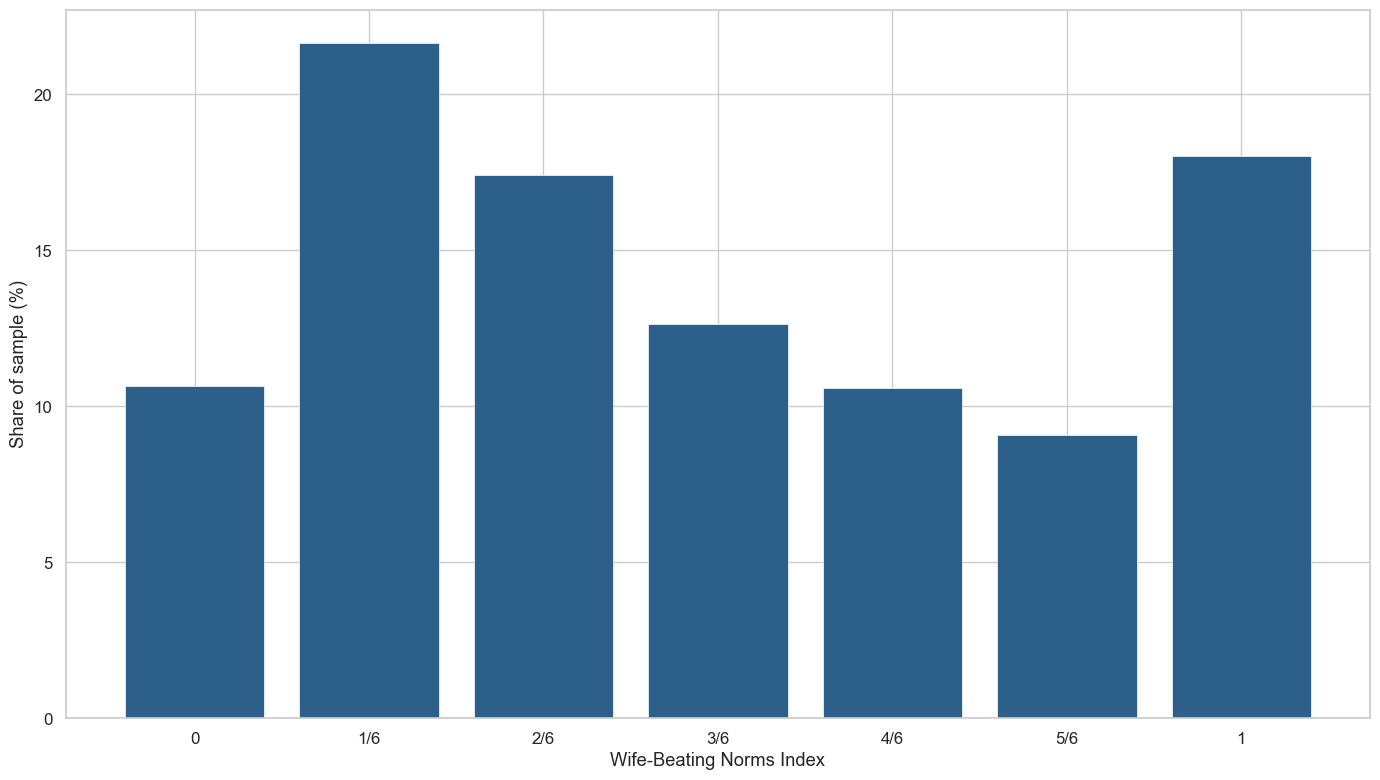

/var/folders/dp/4kgdpbsd4hzdfkvq1xdxsvyr0000gn/T/ipykernel_15773/4145119420.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  urban_tv = (df.groupby(['MM3W', 'URBAN2011'])['wifebeat_index']


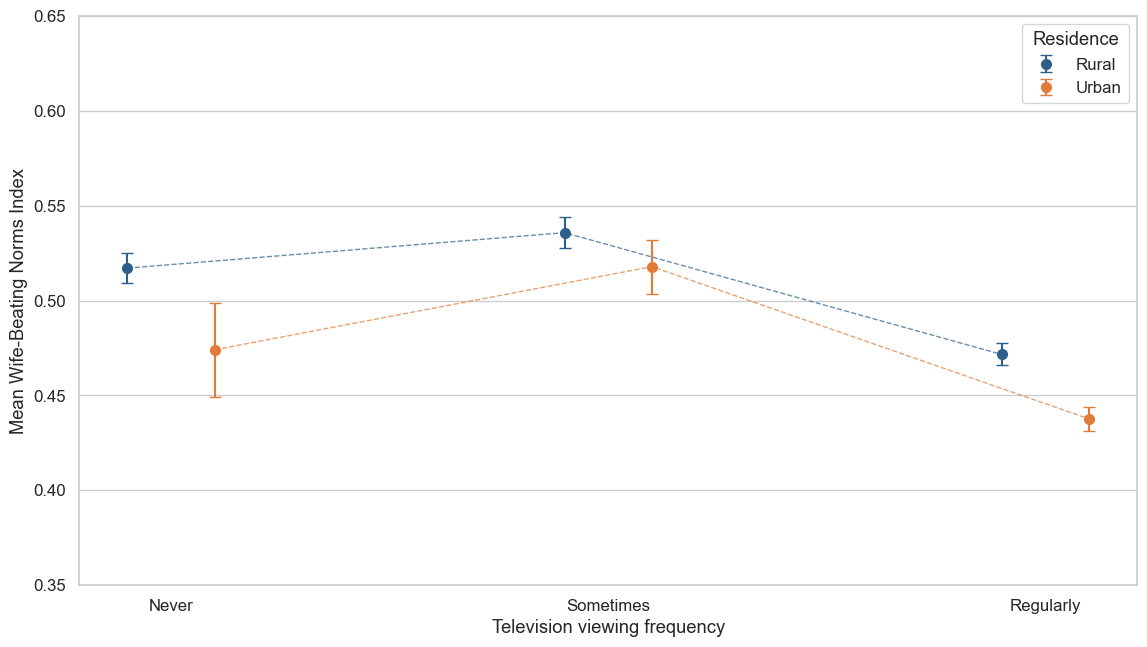

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
BLUE = "#2C5F8A"

# ── 1. Summary statistics table ─────────────────────────────────────────────
cont_vars = ['wifebeat_index', 'ln_COPC', 'EW6', 'EW8', 'SPED6', 'URBAN2011']
summary = df[cont_vars].describe().T[['mean','std','min','max','count']]
summary.index = [
    'Wife-beating index', 'Log consumption per capita',
    'Age', 'Years of education (self)',
    'Years of education (spouse)', 'Urban (=1)'
]
summary.columns = ['Mean', 'Std. Dev.', 'Min', 'Max', 'N']
summary = summary.round(3)
summary['N'] = summary['N'].astype(int)
print(summary.to_latex(float_format="%.2f"))  # paste into your paper

# ── 2. Mean wifebeat_index by TV category ───────────────────────────────────
tv_table = df.groupby('MM3W')['wifebeat_index'].agg(['mean','std','count'])
tv_table.index = ['Never', 'Sometimes', 'Regularly']
tv_table.columns = ['Mean', 'Std. Dev.', 'N']
tv_table = tv_table.round(3)
print(tv_table.to_latex())

# ── 3. Sample composition table ─────────────────────────────────────────────
groups_table = df['GROUPS'].value_counts(normalize=True).sort_index().reset_index()
groups_table.columns = ['Group', 'Share']
groups_table['Share'] = (groups_table['Share'] * 100).round(1)
urban_row = pd.DataFrame({'Group': ['Urban'], 'Share': [round(df['URBAN2011'].mean() * 100, 1)]})
comp_table = pd.concat([groups_table, urban_row], ignore_index=True)
print(comp_table.to_latex(index=False))

# ── Figure 1: Distribution of wifebeat_index ────────────────────────────────
index_vals = df['wifebeat_index'].value_counts(normalize=True).sort_index()
labels = ['0', '1/6', '2/6', '3/6', '4/6', '5/6', '1']

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(labels, index_vals.values * 100, color=BLUE, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Wife-Beating Norms Index')
ax.set_ylabel('Share of sample (%)')
plt.tight_layout()
plt.savefig('04_eda_graphs/fig1_index_distribution.pdf', dpi=300)
plt.show()

# ── Figure 2: Mean index by TV category with 95% CI ─────────────────────────
# Mean wifebeat_index by TV category and urban/rural
urban_tv = (df.groupby(['MM3W', 'URBAN2011'])['wifebeat_index']
              .agg(['mean', 'std', 'count'])
              .reset_index())
urban_tv['se'] = urban_tv['std'] / np.sqrt(urban_tv['count'])
urban_tv['ci'] = 1.96 * urban_tv['se']
urban_tv['tv_label'] = urban_tv['MM3W'].map({
    'Never 1': 'Never',
    'Sometimes 2': 'Sometimes',
    'Regularly 3': 'Regularly'
})
urban_tv['urban_label'] = urban_tv['URBAN2011'].map({
    0: 'Rural',
    1: 'Urban'
})

fig, ax = plt.subplots(figsize=(14/1.2, 8/1.2))

colors = {'Rural': '#2C5F8A', 'Urban': '#E07B39'}
offsets = {'Rural': -0.1, 'Urban': 0.1}
x = np.arange(3)
labels = ['Never', 'Sometimes', 'Regularly']

for group, gdf in urban_tv.groupby('urban_label'):
    gdf = gdf.sort_values('tv_label', key=lambda s: s.map({'Never':0,'Sometimes':1,'Regularly':2}))
    ax.errorbar(x + offsets[group], gdf['mean'], yerr=gdf['ci'],
                fmt='o', color=colors[group], capsize=4,
                markersize=7, linewidth=1.5, label=group)
    ax.plot(x + offsets[group], gdf['mean'], color=colors[group], 
            linewidth=1, linestyle='--', alpha=0.7, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Television viewing frequency')
ax.set_ylabel('Mean Wife-Beating Norms Index')
ax.legend(title='Residence')
ax.set_ylim(0.35, 0.65)
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig('04_eda_graphs/fig2_index_tv_urban.pdf', dpi=300)
plt.show()

In [6]:
state_means = (df.groupby('STATEID')['wifebeat_index']
                 .mean()
                 .reset_index()
                 .round(3))
print(state_means.to_csv(index=False))

STATEID,wifebeat_index
Jammu & Kashmir 01,0.54
Himachal Pradesh 02,0.353
Punjab 03,0.303
Chandigarh 04,0.202
Uttarakhand 05,0.482
Haryana 06,0.359
Delhi 07,0.348
Rajasthan 08,0.356
Uttar Pradesh 09,0.625
Bihar 10,0.481
Sikkim 11,0.461
Arunachal Pradesh 12,0.175
Nagaland 13,0.473
Manipur 14,0.667
Mizoram 15,0.127
Tripura 16,0.414
Meghalaya 17,0.189
Assam 18,0.231
West Bengal 19,0.514
Jharkhand 20,0.195
Orissa 21,0.501
Chhattisgarh 22,0.305
Madhya Pradesh 23,0.39
Gujarat 24,0.344
Daman & Diu 25,0.35
Dadra+Nagar Haveli 26,0.155
Maharashtra 27,0.607
Andhra Pradesh 28,0.747
Karnataka 29,0.69
Goa 30,0.379
Kerala 32,0.456
Tamil Nadu 33,0.563
Pondicherry 34,0.984



/var/folders/dp/4kgdpbsd4hzdfkvq1xdxsvyr0000gn/T/ipykernel_15773/763213614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_means = (df.groupby('STATEID')['wifebeat_index']
